<a href="https://colab.research.google.com/github/mzeeshantahir25/DS-Project/blob/main/0_Correlation_Heatmap.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Maternal Health Risk — Correlation Heatmap & Target Variable

**Project:** Explainable AI (XAI) Framework for Early Detection and Risk Stratification in Maternal Health
**Student:** M. Zesh Tahir
**Supervisor:** Krishna Kedia

**Dataset:** `Dataset - Updated.csv` — 1,205 records, **11 input features** and a
**binary** target (`Risk Level`: Low / High). Combines clinical vital signs with
risk-history indicators (previous complications, diabetes, mental health).


## 1. Imports

In [31]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style='white', context='notebook')
plt.rcParams['figure.dpi'] = 120

FIG_DIR = Path('figures'); FIG_DIR.mkdir(exist_ok=True)

In [32]:
DATA_PATH = Path('Dataset - Updated.csv')
df = pd.read_csv(DATA_PATH)
print('Shape:', df.shape)
df.head()

Shape: (1205, 12)


,Age,Systolic BP,Diastolic,BS,Body Temp,BMI,Previous Complications,Preexisting Diabetes,Gestational Diabetes,Mental Health,Heart Rate,Risk Level
0,22,90.0,60.0,9.0,100,18.0,1.0,1.0,0,1,80.0,High
1,22,110.0,70.0,7.1,98,20.4,0.0,0.0,0,0,74.0,Low
2,27,110.0,70.0,7.5,98,23.0,1.0,0.0,0,0,72.0,Low
3,20,100.0,70.0,7.2,98,21.2,0.0,0.0,0,0,74.0,Low
4,20,90.0,60.0,7.5,98,19.7,0.0,0.0,0,0,74.0,Low


## 2. Load the dataset

## 3. Input features vs. target variable

The updated dataset has **11 input features** and **1 binary target**.

In [33]:
TARGET = 'Risk Level'                              # <-- TARGET VARIABLE
FEATURES = [c for c in df.columns if c != TARGET]  # input features

print('INPUT FEATURES :')
for f in FEATURES:
    print('   -', f)
print('\nTARGET VARIABLE:', TARGET)
print('\nTarget classes :')
print(df[TARGET].value_counts(dropna=False))

INPUT FEATURES :
   - Age
   - Systolic BP
   - Diastolic
   - BS
   - Body Temp
   - BMI
   - Previous Complications
   - Preexisting Diabetes
   - Gestational Diabetes
   - Mental Health
   - Heart Rate

TARGET VARIABLE: Risk Level

Target classes :
Risk Level
Low     713
High    474
NaN      18
Name: count, dtype: int64


## 4. Missing values

The updated file contains some missing entries, including in the target column.

In [34]:
missing = df.isna().sum()
print('Missing values per column:')
print(missing[missing > 0])
print('\nTotal rows with any missing value:', df.isna().any(axis=1).sum())

Missing values per column:
Systolic BP                5
Diastolic                  4
BS                         2
BMI                       18
Previous Complications     2
Preexisting Diabetes       2
Heart Rate                 2
Risk Level                18
dtype: int64

Total rows with any missing value: 39


We drop the rows where the **target** is missing (these can't be used for
supervised learning), and for the correlation we let pandas use pairwise-complete
observations for the remaining feature gaps. Imputation strategy is decided later
in preprocessing.

In [35]:
df = df.dropna(subset=[TARGET]).reset_index(drop=True)
print('Rows after dropping missing target:', len(df))

Rows after dropping missing target: 1187


## 5. Encode the binary target

`Risk Level` is categorical (`Low` / `High`). We map it to **0 / 1** so it can be
included in the correlation analysis (point-biserial correlation).

In [36]:
risk_map = {'Low': 0, 'High': 1}
df_enc = df.copy()
df_enc[TARGET] = df_enc[TARGET].map(risk_map)
print('Encoding:', risk_map)
df_enc[[TARGET]].value_counts()

Encoding: {'Low': 0, 'High': 1}


,count
Risk Level,
0,713
1,474


## 6. Correlation heatmap

Pearson correlation across all input features **and** the encoded target.
The target variable is the last row/column and is highlighted in red.

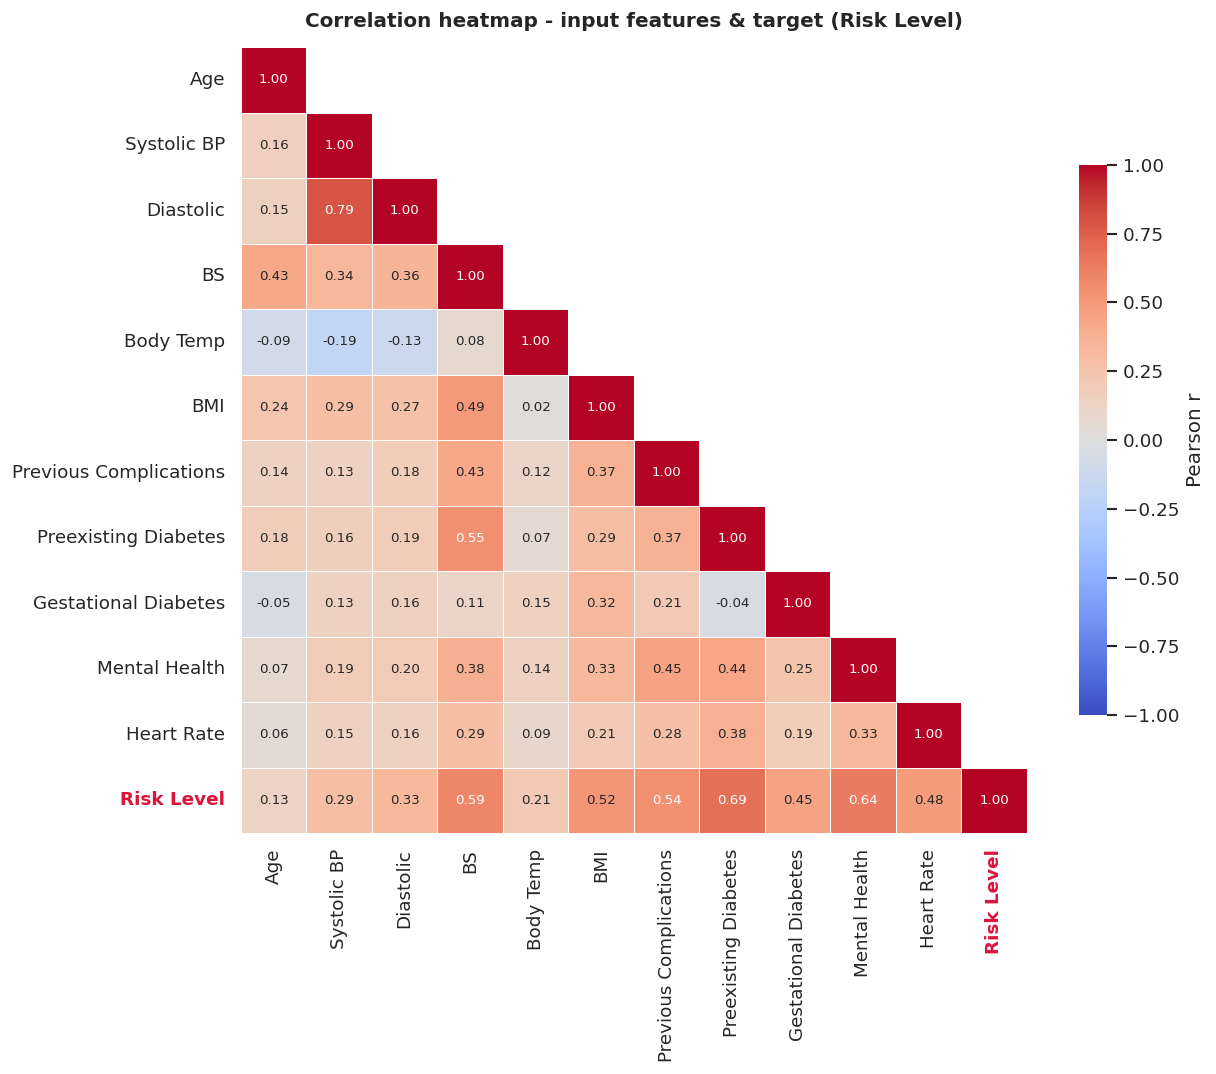

In [37]:
corr = df_enc[FEATURES + [TARGET]].corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.5, linecolor='white',
            annot_kws={'size': 8},
            cbar_kws={'label': 'Pearson r', 'shrink': 0.7}, ax=ax)

for lbl in ax.get_xticklabels() + ax.get_yticklabels():
    if lbl.get_text() == TARGET:
        lbl.set_color('crimson'); lbl.set_fontweight('bold')

ax.set_title('Correlation heatmap - input features & target (Risk Level)',
             fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig(FIG_DIR / '00_correlation_heatmap.png', bbox_inches='tight')
plt.show()

## 7. Correlation of each input feature with the target

Directly answers *"how related is each feature to Risk Level?"*

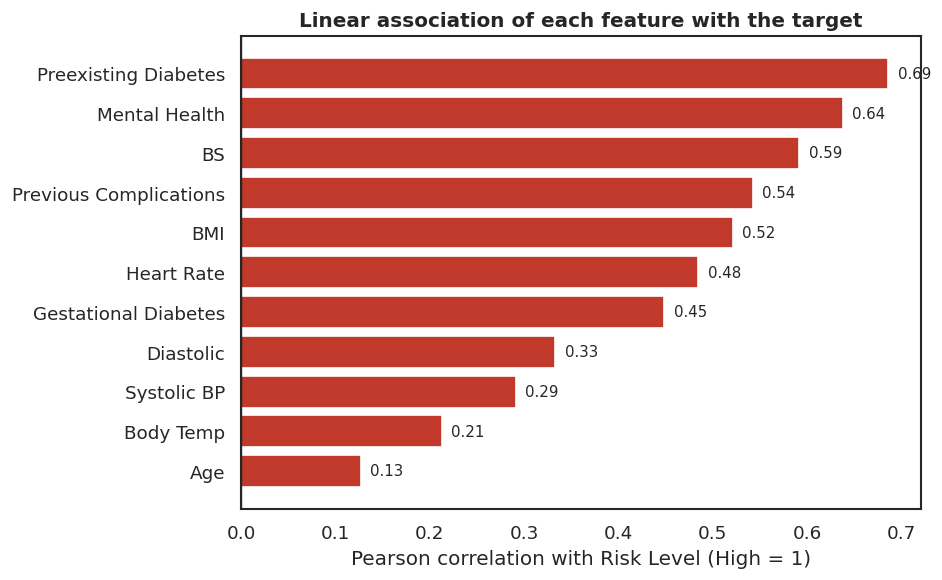

,Risk Level
Preexisting Diabetes,0.686099
Mental Health,0.637888
BS,0.591893
Previous Complications,0.542441
BMI,0.521264
Heart Rate,0.484633
Gestational Diabetes,0.448483
Diastolic,0.332989
Systolic BP,0.291452
Body Temp,0.213079


In [38]:
target_corr = (df_enc[FEATURES + [TARGET]].corr()[TARGET]
               .drop(TARGET).sort_values(ascending=False))

fig, ax = plt.subplots(figsize=(8, 5))
vals = target_corr.values[::-1]
idx = target_corr.index[::-1]
colors = ['#c0392b' if v > 0 else '#2980b9' for v in vals]
ax.barh(idx, vals, color=colors)
ax.axvline(0, color='k', lw=0.8)
ax.set_xlabel('Pearson correlation with Risk Level (High = 1)')
ax.set_title('Linear association of each feature with the target', fontweight='bold')
for i, v in enumerate(vals):
    ax.text(v + (0.01 if v >= 0 else -0.01), i, f'{v:.2f}',
            va='center', ha='left' if v >= 0 else 'right', fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR / '00b_feature_target_corr.png', bbox_inches='tight')
plt.show()

target_corr

## 8. Interpretation — is the dataset suitable?

Correlation of each input feature with the target (`Risk Level`, High = 1):

| Feature | r |
|---|---|
| Preexisting Diabetes | 0.69 |
| Mental Health | 0.64 |
| BS (blood sugar) | 0.59 |
| Previous Complications | 0.54 |
| BMI | 0.52 |
| Heart Rate | 0.49 |
| Gestational Diabetes | 0.45 |
| Diastolic | 0.33 |
| Systolic BP | 0.29 |
| Body Temp | 0.21 |
| Age | 0.13 |

- **Preexisting Diabetes (0.69)**, **Mental Health (0.64)** and **blood sugar / BS (0.59)** are the strongest predictors of high risk — the risk-history flags add real signal beyond vital signs alone, which is exactly what an interpretable clinical model benefits from.
- `BS` and `BMI` are moderately correlated (0.49), and `Systolic BP` / `Diastolic` are strongly inter-correlated (0.79) — flag for multicollinearity in modelling.
- `Age` (0.13) and `Body Temp` (0.21) are the weakest linearly; keep them but expect low individual importance.
- Every feature has a **positive** association with high risk and several are strong, so the dataset is **suitable** for a binary risk-classification model and for an Explainable-AI (SHAP / LIME) analysis.

**Target variable:** `Risk Level` (binary: Low = 0 / High = 1).